# K-Nearest Neighbors

## Intuition

K-Nearest Neighbors (KNN) is the simplest possible non-parametric classifier. There is no training phase. The model memorizes the entire training set and, when asked to classify a new point, simply finds the $k$ closest training examples and takes a majority vote.

The philosophy is: similar inputs should have similar outputs. If $k=5$ and 4 of the 5 nearest neighbors are labeled "heart disease," the model predicts heart disease for the query point.

This approach works remarkably well in many settings, but its power comes at a cost: every prediction requires scanning all training points to compute distances.

---

## Math

**Euclidean distance.** For two points $\mathbf{x}$ and $\mathbf{x}^{(i)}$ in $\mathbb{R}^n$:

$$d(\mathbf{x}, \mathbf{x}^{(i)}) = \sqrt{\sum_{j=1}^{n} (x_j - x_j^{(i)})^2}$$

**Majority vote.** After finding the $k$ nearest neighbors $\mathcal{N}_k(\mathbf{x})$:

$$\hat{y} = \underset{c}{\arg\max} \sum_{i \in \mathcal{N}_k(\mathbf{x})} \mathbf{1}[y^{(i)} = c]$$

**Bias-variance tradeoff with $k$.**
- Small $k$ (e.g., $k=1$): low bias, high variance. the decision boundary is jagged and fits noise.
- Large $k$ (e.g., $k=N$): high bias, low variance. the decision boundary smooths toward predicting the majority class.

---

## Algorithm Steps

**Fit (training):**
1. Store all training samples $(\mathbf{x}^{(i)}, y^{(i)})$ in memory.

**Predict (for a new point $\mathbf{x}$):**
1. Compute distance $d(\mathbf{x}, \mathbf{x}^{(i)})$ to every training point.
2. Sort by distance and take the $k$ smallest.
3. Count votes for each class among the $k$ neighbors.
4. Return the class with the most votes.

---

## Advantages

- Extremely simple to understand and implement.
- No assumptions about the data distribution (non-parametric).
- Naturally handles multi-class classification without modification.
- No training time. the "model" is just the stored dataset.
- Adapts automatically to non-linear and irregular decision boundaries.

## Disadvantages

- Slow at prediction time: $O(N \cdot n)$ per query (must scan all $N$ training points of dimension $n$).
- High memory usage: must store the entire training set.
- Sensitive to feature scale: features with larger ranges dominate the distance (requires StandardScaler).
- Suffers from the curse of dimensionality: in high dimensions, all points become roughly equidistant, making nearest neighbors meaningless.
- Sensitive to noisy or irrelevant features.

## Solutions to Disadvantages

- Use **KD-trees or ball trees** to speed up neighbor lookups from $O(N)$ to $O(\log N)$.
- Apply **StandardScaler** (or MinMaxScaler) before fitting to equalize feature ranges.
- Apply **PCA or feature selection** to reduce dimensionality before KNN.
- Use **weighted voting** (weight by $1/d$) to reduce the influence of distant neighbors.
- Use **cross-validation** to select the optimal $k$.

---

## Summary

| Property | Value |
|---|---|
| Type | Non-parametric classifier or regressor |
| Training time | $O(1)$ (just stores data) |
| Prediction time | $O(N \cdot n)$ per query |
| Decision boundary | Non-linear (arbitrary shape) |
| Output | Hard class label (majority vote) |
| Key hyperparameter | $k$ (number of neighbors) |
| Requires scaling | Yes (distance-based) |

**Dataset:** Heart Disease (`heart.csv`). 1025 samples, 13 clinical features. Binary classification: predict heart disease (0 = no disease, 1 = disease).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme()

from rice_ml.supervised_learning import KNN
from rice_ml.preprocess import StandardScaler, train_test_split
from rice_ml.metrics import accuracy_score, confusion_matrix

In [2]:
try:
    df = pd.read_csv('../../../data/heart.csv')
    X = df.drop(columns=['target']).values.astype(float)
    y = df['target'].values
    feature_names = df.drop(columns=['target']).columns.tolist()
    class_names = ['No Disease', 'Heart Disease']
    print(f'Loaded heart dataset: {X.shape}')
except FileNotFoundError:
    from sklearn.datasets import load_iris
    iris = load_iris()
    X, y = iris.data, iris.target
    feature_names = iris.feature_names
    class_names = list(iris.target_names)
    df = None
    print('CSV not found. using iris dataset')

print(f'Dataset shape: {X.shape}')
print(f'Classes: {class_names}')

Loaded heart dataset: (1025, 13)
Dataset shape: (1025, 13)
Classes: ['No Disease', 'Heart Disease']


## Dataset Description

The **Heart Disease dataset** (`heart.csv`) contains 1025 patient records from the UCI Heart Disease repository. Each row represents one patient with 13 clinical and demographic features:
[Download from Kaggle](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset)


| Feature | Description |
|---|---|
| age | Age in years |
| sex | Sex (1 = male, 0 = female) |
| cp | Chest pain type (0-3, where 0 = typical angina) |
| trestbps | Resting blood pressure (mm Hg) |
| chol | Serum cholesterol (mg/dl) |
| fbs | Fasting blood sugar > 120 mg/dl (1 = true) |
| restecg | Resting ECG results (0-2) |
| thalach | Maximum heart rate achieved during exercise |
| exang | Exercise-induced angina (1 = yes) |
| oldpeak | ST depression induced by exercise relative to rest |
| slope | Slope of peak exercise ST segment (0-2) |
| ca | Number of major vessels colored by fluoroscopy (0-3) |
| thal | Thalassemia type (1 = normal, 2 = fixed defect, 3 = reversible defect) |

**Target:** `target` (1 = heart disease present, 0 = absent).

KNN is a natural choice here: heart disease risk can be assessed by finding similar past patients and looking at their diagnoses. Feature scaling is critical since features like cholesterol (200 mg/dl) have a much larger absolute range than binary features like fbs (0 or 1).

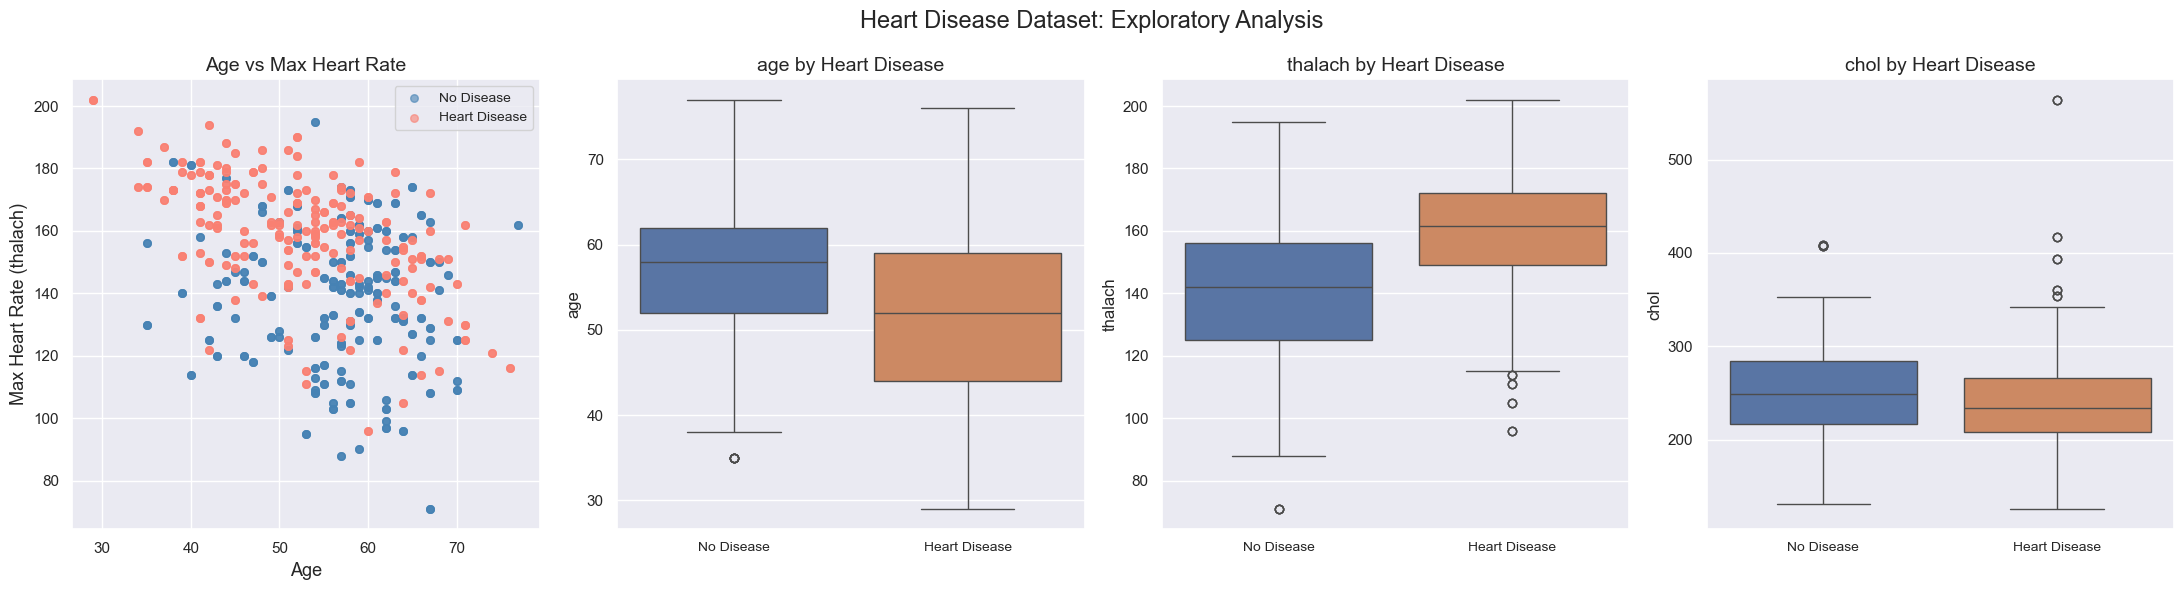

Mean values by class:
                     age     thalach        chol
target                                          
No Disease     56.569138  139.130261  251.292585
Heart Disease  52.408745  158.585551  240.979087


In [3]:
# EDA: Scatter of age vs thalach colored by class; Boxplots of age, thalach, chol by target
if df is not None:
    fig, axes = plt.subplots(1, 4, figsize=(22, 6))
    colors = {0: 'steelblue', 1: 'salmon'}
    labels_map = {0: 'No Disease', 1: 'Heart Disease'}
    df_plot = df.copy()
    df_plot['Disease'] = df_plot['target'].map(labels_map)

    for cls in [0, 1]:
        mask = df_plot['target'] == cls
        axes[0].scatter(df_plot.loc[mask, 'age'], df_plot.loc[mask, 'thalach'],
                        c=colors[cls], label=labels_map[cls], alpha=0.6, s=30)
    axes[0].set_xlabel('Age', fontsize=13)
    axes[0].set_ylabel('Max Heart Rate (thalach)', fontsize=13)
    axes[0].set_title('Age vs Max Heart Rate', fontsize=14)
    axes[0].legend(fontsize=10)

    for ax, feat in zip(axes[1:], ['age', 'thalach', 'chol']):
        sns.boxplot(data=df_plot, x='Disease', y=feat, hue='Disease', legend=False, ax=ax)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['No Disease', 'Heart Disease'], fontsize=10)
        ax.set_title(f'{feat} by Heart Disease', fontsize=14)
        ax.set_xlabel('')

    plt.suptitle('Heart Disease Dataset: Exploratory Analysis', fontsize=17)
    plt.tight_layout()
    plt.show()

    print('Mean values by class:')
    print(df.groupby('target')[['age', 'thalach', 'chol']].mean().rename(index={0: 'No Disease', 1: 'Heart Disease'}).to_string())
else:
    print('EDA skipped: using fallback dataset.')


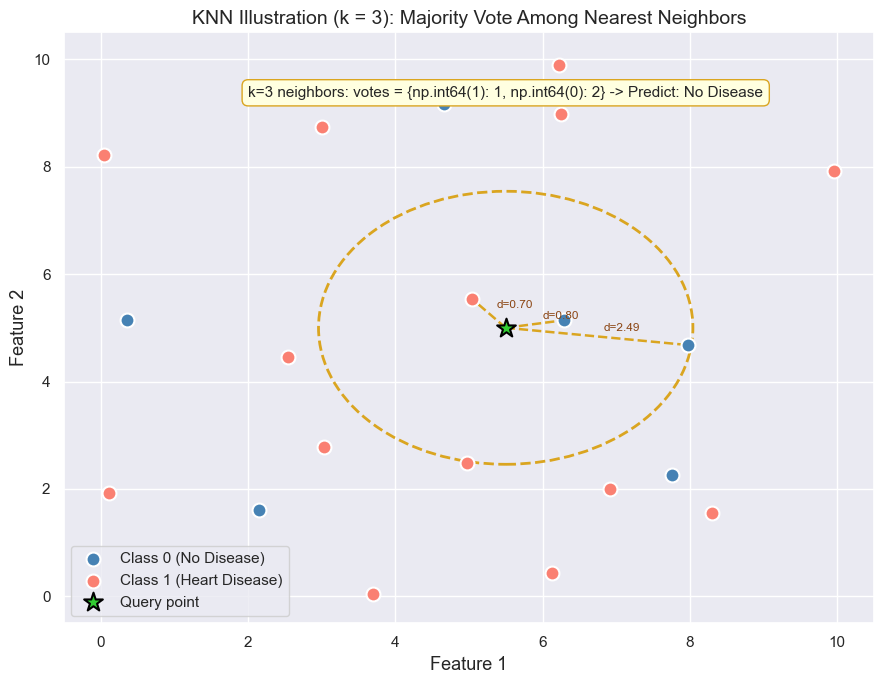

In [4]:
# Diagram: KNN illustration with k=3
# 15 random 2D points colored by class, one query point, circle showing 3 nearest neighbors

rng = np.random.default_rng(7)
n_pts = 20
pts = rng.uniform(0, 10, (n_pts, 2))
labels_illus = rng.integers(0, 2, n_pts)

# Query point
query = np.array([5.5, 5.0])

# Compute distances from query to all points
dists = np.sqrt(((pts - query) ** 2).sum(axis=1))
k = 3
nn_idx = np.argsort(dists)[:k]
radius = dists[nn_idx[-1]] + 0.05  # just past the k-th neighbor

fig, ax = plt.subplots(figsize=(9, 7))

# Plot background points
colors_illus = ['steelblue', 'salmon']
labels_illus_names = ['Class 0 (No Disease)', 'Class 1 (Heart Disease)']
for cls in [0, 1]:
    mask = labels_illus == cls
    ax.scatter(pts[mask, 0], pts[mask, 1], c=colors_illus[cls],
               label=labels_illus_names[cls], s=100, edgecolors='white', lw=1.5, zorder=3)

# Draw distance lines to k nearest neighbors
nn_votes = []
for i, idx in enumerate(nn_idx):
    ax.plot([query[0], pts[idx, 0]], [query[1], pts[idx, 1]],
            color='goldenrod', lw=1.8, linestyle='--', zorder=2)
    ax.text((query[0] + pts[idx, 0]) / 2 + 0.1,
            (query[1] + pts[idx, 1]) / 2 + 0.1,
            f'd={dists[idx]:.2f}', fontsize=8.5, color='saddlebrown')
    nn_votes.append(labels_illus[idx])

# Draw circle
circle = plt.Circle(query, radius, color='goldenrod', fill=False, lw=2.0, linestyle='--', zorder=2)
ax.add_patch(circle)

# Draw query point
ax.scatter(*query, c='limegreen', s=200, marker='*', zorder=5, edgecolors='black', lw=1.5, label='Query point')

# Majority vote result
from collections import Counter
vote = Counter(nn_votes).most_common(1)[0][0]
vote_name = labels_illus_names[vote].split('(')[1].rstrip(')')
ax.text(5.5, 9.3, f'k={k} neighbors: votes = {dict(Counter(nn_votes))} -> Predict: {vote_name}',
        ha='center', fontsize=11,
        bbox=dict(boxstyle='round,pad=0.4', fc='lightyellow', ec='goldenrod'))

ax.set_xlim(-0.5, 10.5)
ax.set_ylim(-0.5, 10.5)
ax.set_xlabel('Feature 1', fontsize=13)
ax.set_ylabel('Feature 2', fontsize=13)
ax.set_title(f'KNN Illustration (k = {k}): Majority Vote Among Nearest Neighbors', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

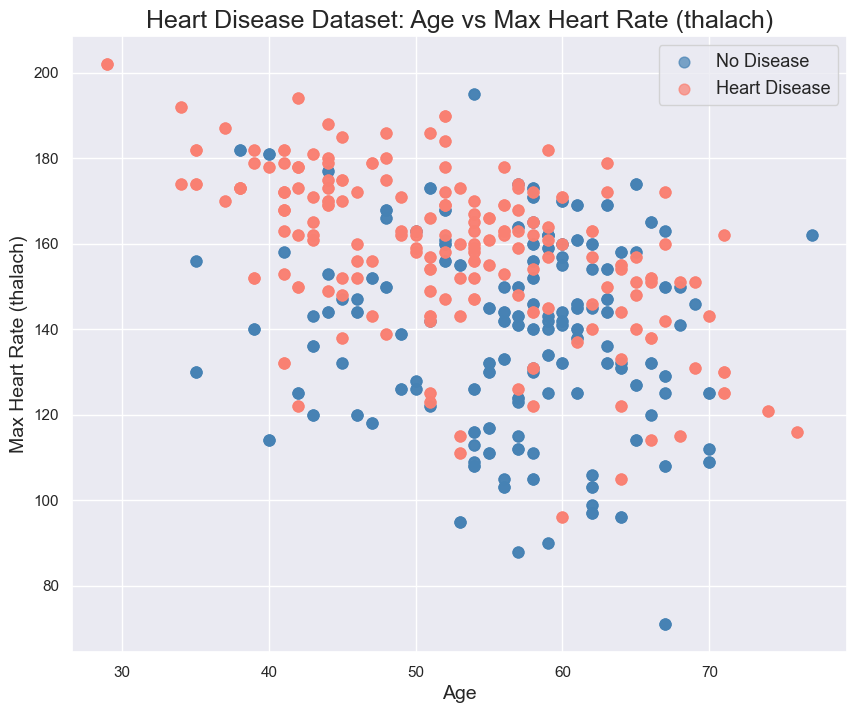

In [5]:
# Visualize age vs thalach (the two most clinically meaningful features)
colors = ['steelblue', 'salmon']
plt.figure(figsize=(10, 8))
for i, cls in enumerate(class_names):
    mask = y == i
    plt.scatter(df['age'].values[mask] if df is not None else X[mask, 0],
                df['thalach'].values[mask] if df is not None else X[mask, 7],
                c=colors[i % len(colors)], label=cls, s=60, alpha=0.7)
plt.xlabel('Age', fontsize=14)
plt.ylabel('Max Heart Rate (thalach)', fontsize=14)
plt.title('Heart Disease Dataset: Age vs Max Heart Rate (thalach)', fontsize=18)
plt.legend(fontsize=13)
plt.show()

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

## Choosing $k$. Accuracy vs Number of Neighbors

A small $k$ leads to high variance (overfitting); a large $k$ leads to high bias (underfitting).

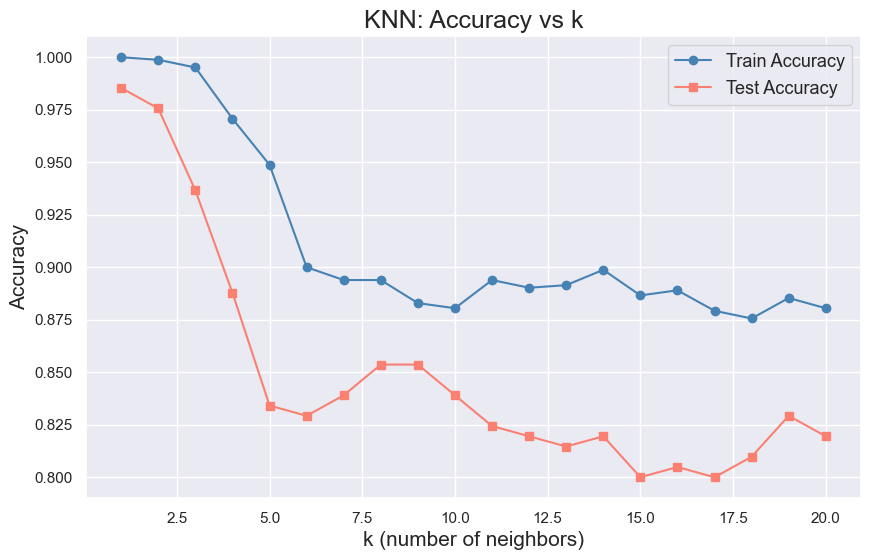

Best k = 1, Test Accuracy = 0.9854


In [7]:
k_values = range(1, 21)
train_accs, test_accs = [], []

for k in k_values:
    clf = KNN(k=k)
    clf.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, clf.predict(X_train)))
    test_accs.append(accuracy_score(y_test, clf.predict(X_test)))

plt.figure(figsize=(10, 6))
plt.plot(k_values, train_accs, marker='o', label='Train Accuracy', color='steelblue')
plt.plot(k_values, test_accs, marker='s', label='Test Accuracy', color='salmon')
plt.xlabel('k (number of neighbors)', fontsize=15)
plt.ylabel('Accuracy', fontsize=15)
plt.title('KNN: Accuracy vs k', fontsize=18)
plt.legend(fontsize=13)
plt.show()

best_k = list(k_values)[np.argmax(test_accs)]
print(f'Best k = {best_k}, Test Accuracy = {max(test_accs):.4f}')

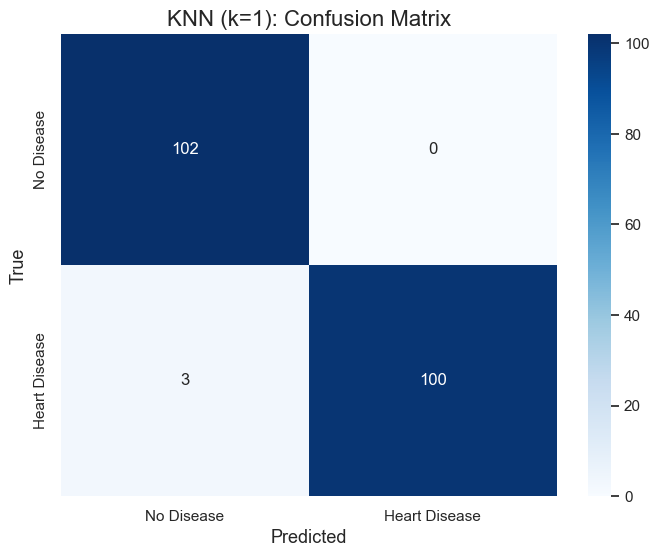

In [8]:
best_clf = KNN(k=best_k).fit(X_train, y_train)
y_pred = best_clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted', fontsize=13)
plt.ylabel('True', fontsize=13)
plt.title(f'KNN (k={best_k}): Confusion Matrix', fontsize=16)
plt.show()

## Interpretation

**No training phase:** KNN is a lazy learner. all computation happens at prediction time. This means adding new training data is free (just append to the stored set), but each prediction is $O(N)$.

**Accuracy vs k curve:** At $k=1$, training accuracy is always 1.0 (each point is its own nearest neighbor). Test accuracy peaks at a moderate $k$ and then decreases as the model becomes too biased toward the majority class. The optimal $k$ balances fitting the local structure of the data without memorizing noise.

**Effect of scaling:** StandardScaler is critical here. Without it, features like cholesterol (range 100-600 mg/dl) would dominate the Euclidean distance over binary features like fbs (range 0-1), causing the model to effectively ignore the smaller-scaled features.

**Clinical interpretation:** The scatter plot shows that older patients with lower max heart rates (thalach) tend to have heart disease. KNN captures this spatial pattern directly: a new elderly patient with low thalach will be surrounded by heart disease cases in the feature space.

**Comparison to other models:** KNN achieves competitive accuracy but would not scale to a dataset with 100,000 patients without tree-based indexing. Logistic Regression or a Decision Tree would be faster at prediction time and more interpretable.